<a href="https://colab.research.google.com/github/mxchelletanx/mxchelletanx.github.io/blob/master/9670294v_TanYanLingMichelle_ITD224_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ITD224: U.S. MOVIE ROI PROXY PREDICTION FOR CONTENT DECISION-MAKING**

## Strategic Context & Team Alignment
As part of our consulting engagement to provide the movie app development team with data on revenue and genres for their streaming platform, this module addresses **Objective 2: Maximising Return on Content Licensing Spend**.

The primary objective is to construct an interpretable supervised regression model to predict a historical movie ROI Proxy for U.S. feature films using attributes intended to be available before release (including budget, runtime, release timing, genres, and production companies). This allows the streaming platform to identify historically attractive content using predicted ROI Proxy values as one input to illustrative content-selection decisions, subject to human judgement and further commercial assessment.

In [1]:
# Install required packages
# !pip install xgboost lightgbm openpyxl -q

import ast
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

from google.colab import drive
try:
    drive.mount('/content/drive')
    print("[INFO] Google Drive mounted successfully.")
except Exception as e:
    print(f"[WARNING] Google Drive mount skipped or failed: {e}")

np.random.seed(42)
print("[INFO] Environment setup completed successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] Google Drive mounted successfully.
[INFO] Environment setup completed successfully.


## **Section 1: Data Loading & Data Quality Validation**
This section loads the cleaned dataset from Google Drive, performs structural integrity checks, identifies and removes exact duplicate rows, analyses missing value patterns, and applies initial data-quality cleaning before operational scope filtering.

In [2]:
file_path = '/content/drive/MyDrive/data_movies_clean.xlsx'

try:
    df_raw = pd.read_excel(file_path, engine='openpyxl')
    print(f"[INFO] Cleaned dataset successfully loaded with shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]:,} columns.")
except FileNotFoundError:
    raise FileNotFoundError(f"[ERROR] File not found at '{file_path}'. Please verify your Google Drive path.")

print("\n" + "="*60)
print("1. DATA SHAPE & DUPLICATES")
print("="*60)
duplicate_count = df_raw.duplicated().sum()

shape_summary_df = pd.DataFrame({
    'Metric': ['Total Rows', 'Total Columns', 'Exact Duplicate Rows Detected'],
    'Value': [f"{df_raw.shape[0]:,}", f"{df_raw.shape[1]:,}", f"{duplicate_count:,}"]
})
print(shape_summary_df.to_string(index=False))

if duplicate_count > 0:
    df_raw = df_raw.drop_duplicates().copy()
    print(f"[INFO] Removed {duplicate_count:,} exact duplicate rows before modelling.")

print("\n" + "="*60)
print("2. DATA QUALITY SUMMARY TABLE")
print("="*60)

quality_summary = pd.DataFrame({
    'Data Type': df_raw.dtypes,
    'Missing Count': df_raw.isnull().sum(),
    'Missing Percentage (%)': ((df_raw.isnull().sum() / len(df_raw)) * 100).round(2)
})
print(quality_summary[quality_summary['Missing Count'] > 0].to_string())

df_clean = df_raw.dropna(subset=['title']).copy()
if 'genre_names' in df_clean.columns:
    df_clean['genre_names'] = df_clean['genre_names'].replace('[]', np.nan)
if 'production_company_names' in df_clean.columns:
    df_clean['production_company_names'] = df_clean['production_company_names'].replace('[]', np.nan)

df_clean['revenue'] = pd.to_numeric(df_clean['revenue'], errors='coerce')
df_clean['runtime'] = pd.to_numeric(df_clean['runtime'], errors='coerce')
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')

df_clean = df_clean[df_clean['revenue'] >= 0]
df_clean = df_clean[(df_clean['runtime'] >= 10) & (df_clean['runtime'] <= 300)]

print("\n[INFO] Structural integrity validation and quality summary compiled successfully.")

[INFO] Cleaned dataset successfully loaded with shape: 946,460 rows, 14 columns.

1. DATA SHAPE & DUPLICATES
                       Metric   Value
                   Total Rows 946,460
                Total Columns      14
Exact Duplicate Rows Detected       0

2. DATA QUALITY SUMMARY TABLE
      Data Type  Missing Count  Missing Percentage (%)
title    object              9                     0.0

[INFO] Structural integrity validation and quality summary compiled successfully.


## **Section 2: Target Definition & Operational Scope Filtering**
The target variable is defined as a revenue-to-budget **ROI Proxy**:

$$
\text{ROI Proxy} = \frac{\text{Revenue} - \text{Budget}}{\text{Budget}}
$$

The ROI Proxy is lower-clipped at -0.99 before applying the log transformation so that the log-transformed target remains defined. The log transformation reduces the right-skewness of the target distribution using Log-Transformed ROI Proxy ($ \log(1 + \text{ROI Proxy}_{\text{clipped}}) $).

### Operational Scope Filters:
- **U.S.-Origin Scope:** Filtered to titles whose recorded origin-country list includes the country code US.
- **Language Scope:** Retained English-language films.
- **Financial Scope:** Retained films with budget >= 100,000 USD and revenue > 0 USD.
- **Duration Scope:** Runtimes between 40 and 300 minutes to focus the modelling population on longer-form film content and exclude very short or implausibly long records.

In [3]:
required_scope_columns = [
    'origin_country', 'original_language', 'budget', 'revenue',
    'runtime', 'release_date', 'genre_names', 'production_company_names'
]
missing_scope_columns = [col for col in required_scope_columns if col not in df_clean.columns]
if missing_scope_columns:
    raise KeyError(f"Missing required scope columns: {missing_scope_columns}")

df = df_clean.copy()
initial_count = len(df)

def has_us_origin(val):
    if isinstance(val, list):
        return 'US' in [str(x).strip() for x in val]
    if pd.isna(val):
        return False
    try:
        parsed = ast.literal_eval(str(val))
        if isinstance(parsed, list):
            return 'US' in [str(x).strip() for x in parsed]
    except (ValueError, SyntaxError):
        pass
    return str(val).strip() == 'US'

df = df[df['origin_country'].apply(has_us_origin)]
df = df[df['original_language'] == 'en']

df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df = df[(df['budget'] >= 100000) & (df['revenue'] > 0)].copy()
df = df[(df['runtime'] >= 40) & (df['runtime'] <= 300)].copy()
df = df.dropna(subset=['release_date']).copy()

df['roi_raw'] = (df['revenue'] - df['budget']) / df['budget']
df['roi_clipped'] = df['roi_raw'].clip(lower=-0.99)
df['target_log_roi'] = np.log1p(df['roi_clipped'])

scope_audit_df = pd.DataFrame({
    'Scope Audit Metric': [
        'Initial Records Post-Clean',
        'Records Retained in Scope',
        'Records Filtered Out',
        'Final Modelling Dataset Size'
    ],
    'Count': [
        f"{initial_count:,}",
        f"{len(df):,}",
        f"{initial_count - len(df):,}",
        f"{df.shape[0]:,} movies remaining"
    ]
})
print("="*60)
print("SCOPE FILTERING AUDIT SUMMARY")
print("="*60)
print(scope_audit_df.to_string(index=False))

SCOPE FILTERING AUDIT SUMMARY
          Scope Audit Metric                    Count
  Initial Records Post-Clean                  635,534
   Records Retained in Scope                  162,463
        Records Filtered Out                  473,071
Final Modelling Dataset Size 162,463 movies remaining


## **Section 3: Exploratory Data Analysis & Target Distribution**
This section visualises the effect of the log transformation on the target distribution. The raw ROI Proxy plot excludes the upper 5% of observations for visualisation only to improve visibility of the central distribution; the underlying dataset remains unchanged and the full dataset is retained for modelling. Skewness and kurtosis diagnostics are used to assess how the transformation changes the distribution.

TARGET DISTRIBUTION DIAGNOSTICS
     Distribution Measure  Skewness  Kurtosis
            Raw ROI Proxy    202.98  62380.51
Log-Transformed ROI Proxy     -0.30      2.21




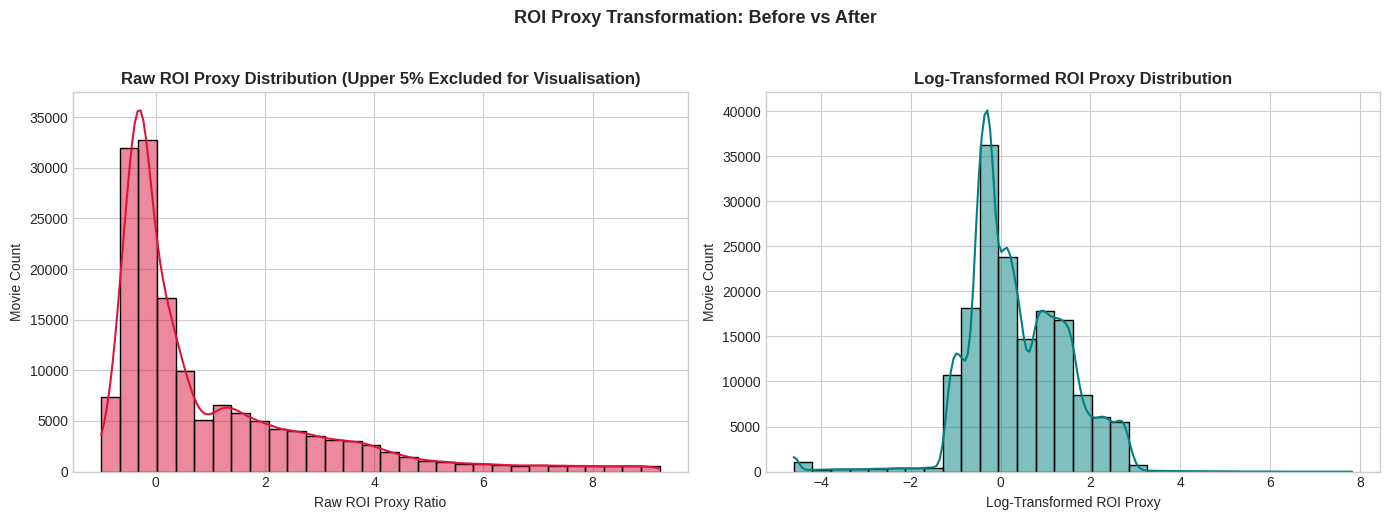

In [4]:
print("="*60)
print("TARGET DISTRIBUTION DIAGNOSTICS")
print("="*60)

target_diag_df = pd.DataFrame({
    'Distribution Measure': ['Raw ROI Proxy', 'Log-Transformed ROI Proxy'],
    'Skewness': [round(df['roi_raw'].skew(), 2), round(df['target_log_roi'].skew(), 2)],
    'Kurtosis': [round(df['roi_raw'].kurtosis(), 2), round(df['target_log_roi'].kurtosis(), 2)]
})
print(target_diag_df.to_string(index=False))
print("\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p95_value = np.percentile(df['roi_raw'], 95)
df_p95 = df[df['roi_raw'] <= p95_value]

sns.histplot(df_p95['roi_raw'], kde=True, ax=axes[0], bins=30, color='crimson')
axes[0].set_title("Raw ROI Proxy Distribution (Upper 5% Excluded for Visualisation)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Raw ROI Proxy Ratio")
axes[0].set_ylabel("Movie Count")

sns.histplot(df['target_log_roi'], kde=True, ax=axes[1], bins=30, color='teal')
axes[1].set_title("Log-Transformed ROI Proxy Distribution", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Log-Transformed ROI Proxy")
axes[1].set_ylabel("Movie Count")

plt.suptitle("ROI Proxy Transformation: Before vs After", fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## **Section 4: Train/Test Split & Feature Engineering**
To prevent leakage from the held-out test set, learned preprocessing parameters, including feature encodings, studio-frequency selection and standardisation, are derived from the training partition only. Deterministic feature transformations that do not require fitting are applied before the split and do not use information from the target or other observations.

Budget is intentionally retained as a predictor because it may be available during pre-release content planning and is a component of the ROI Proxy calculation. This creates a structural relationship between the predictor and target, but does not constitute target leakage because the target's post-release revenue component is not used as a predictor. Historical release timing is used as a proxy for timing information that may have been available at the pre-release decision point; however, the observed release date may differ from the originally planned release timing.

In [5]:
import re

def make_safe_feature_name(prefix, value):
    safe_value = re.sub(r'[^A-Za-z0-9_]+', '_', str(value)).strip('_')
    return f"{prefix}_{safe_value}"

df['release_month'] = df['release_date'].dt.month
df['budget_log'] = np.log1p(df['budget'])

def parse_list_column(val):
    if isinstance(val, list):
        return val
    if pd.isna(val):
        return []
    try:
        parsed = ast.literal_eval(str(val))
        return parsed if isinstance(parsed, list) else []
    except (ValueError, SyntaxError):
        return []

df['genre_list'] = df['genre_names'].apply(parse_list_column)
df['studio_list'] = df['production_company_names'].apply(parse_list_column)

train_df, test_df = train_test_split(df, test_size=0.20, random_state=42)
print(f"[INFO] Train size: {len(train_df):,} | Test size: {len(test_df):,}")

# Fit preprocessing on the training partition for held-out test transformation
mlb_genre = MultiLabelBinarizer()
mlb_genre.fit(train_df['genre_list'])

train_all_studios = [studio for sublist in train_df['studio_list'] for studio in sublist]
top_20_studios = list(pd.Series(train_all_studios).value_counts().head(20).index)

numeric_features = ['budget_log', 'runtime', 'release_month']
train_runtime_median = train_df['runtime'].median()

def extract_features(subset_df, fitted_mlb, fitted_studios, runtime_med):
    X_num = subset_df[numeric_features].copy()
    X_num['runtime'] = X_num['runtime'].fillna(runtime_med)

    genre_encoded = fitted_mlb.transform(subset_df['genre_list'])
    genre_sub = pd.DataFrame(genre_encoded, columns=[make_safe_feature_name('genre', g) for g in fitted_mlb.classes_], index=subset_df.index)

    studio_sub = pd.DataFrame(index=subset_df.index)
    for studio in fitted_studios:
        studio_col = make_safe_feature_name('studio', studio)
        studio_sub[studio_col] = subset_df['studio_list'].apply(lambda x: 1 if studio in x else 0)

    return pd.concat([X_num, genre_sub, studio_sub], axis=1)

X_train_raw = extract_features(train_df, mlb_genre, top_20_studios, train_runtime_median)
X_test_raw = extract_features(test_df, mlb_genre, top_20_studios, train_runtime_median)
y_train = train_df['target_log_roi']
y_test = test_df['target_log_roi']

scaler = StandardScaler()
X_train_scaled_num = pd.DataFrame(scaler.fit_transform(X_train_raw[numeric_features]), columns=numeric_features, index=X_train_raw.index)
X_test_scaled_num = pd.DataFrame(scaler.transform(X_test_raw[numeric_features]), columns=numeric_features, index=X_test_raw.index)

bin_cols = [c for c in X_train_raw.columns if c not in numeric_features]
X_train = pd.concat([X_train_scaled_num, X_train_raw[bin_cols]], axis=1)
X_test = pd.concat([X_test_scaled_num, X_test_raw[bin_cols]], axis=1)

print(f"[INFO] Feature extraction complete. X_train: {X_train.shape} | X_test: {X_test.shape}")

[INFO] Train size: 129,970 | Test size: 32,493
[INFO] Feature extraction complete. X_train: (129970, 42) | X_test: (32493, 42)


## **Section 5: Model Selection & Cross-Validation**
Candidate models are benchmarked using stratified cross-validation, with the training data partitioned approximately by budget quintiles to promote broadly similar budget distributions across folds. Preprocessing steps, including genre encoding, studio-frequency selection and standardisation, are fitted independently within each training fold and applied to the corresponding validation fold to prevent validation leakage. Mean and standard deviation of the evaluation metrics are reported across folds to assess predictive performance and model stability.

In [6]:
cv_n_splits = 5
train_budget_quantiles = pd.qcut(
    train_df['budget'],
    q=cv_n_splits,
    labels=False,
    duplicates='drop'
)
skf = StratifiedKFold(
    n_splits=cv_n_splits,
    shuffle=True,
    random_state=42
)
cv_splits = list(
    skf.split(train_df, train_budget_quantiles)
)
models = {
    "LightGBM": LGBMRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        verbose=-1,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    "Ridge Regression": Ridge(alpha=1.0)
}

print("=" * 150)
print("MODEL BENCHMARKING EVALUATION")
print("=" * 150)
print(
    f"[INFO] Benchmarking {len(models)} candidate models "
    f"using {cv_n_splits}-fold stratified cross-validation."
)

results = []
for name, model in models.items():
    start_time = time.time()

    cv_r2_scores = []
    cv_rmse_scores = []
    cv_mae_scores = []

    for train_idx, val_idx in cv_splits:
        fold_train_df = train_df.iloc[train_idx]
        fold_val_df = train_df.iloc[val_idx]

        fold_mlb = MultiLabelBinarizer()
        fold_mlb.fit(fold_train_df['genre_list'])

        fold_all_studios = [studio for sublist in fold_train_df['studio_list'] for studio in sublist]
        fold_top_studios = list(pd.Series(fold_all_studios).value_counts().head(20).index)
        fold_runtime_med = fold_train_df['runtime'].median()

        X_fold_train_raw = extract_features(fold_train_df, fold_mlb, fold_top_studios, fold_runtime_med)
        X_fold_val_raw = extract_features(fold_val_df, fold_mlb, fold_top_studios, fold_runtime_med)

        fold_scaler = StandardScaler()
        X_fold_train_num = pd.DataFrame(fold_scaler.fit_transform(X_fold_train_raw[numeric_features]), columns=numeric_features, index=X_fold_train_raw.index)
        X_fold_val_num = pd.DataFrame(fold_scaler.transform(X_fold_val_raw[numeric_features]), columns=numeric_features, index=X_fold_val_raw.index)

        fold_bin_cols = [c for c in X_fold_train_raw.columns if c not in numeric_features]
        X_fold_train = pd.concat([X_fold_train_num, X_fold_train_raw[fold_bin_cols]], axis=1)
        X_fold_val = pd.concat([X_fold_val_num, X_fold_val_raw[fold_bin_cols]], axis=1)

        y_fold_train = fold_train_df['target_log_roi']
        y_fold_val = fold_val_df['target_log_roi']

        model.fit(X_fold_train, y_fold_train)
        preds = model.predict(X_fold_val)

        cv_r2_scores.append(r2_score(y_fold_val, preds))
        cv_rmse_scores.append(np.sqrt(mean_squared_error(y_fold_val, preds)))
        cv_mae_scores.append(mean_absolute_error(y_fold_val, preds))

    elapsed = round(time.time() - start_time, 2)

    mean_r2 = np.mean(cv_r2_scores)
    mean_rmse = np.mean(cv_rmse_scores)
    mean_mae_log = np.mean(cv_mae_scores)

    results.append({
        "Model": name,
        "CV R² Mean": round(mean_r2, 4),
        "CV R² SD": round(np.std(cv_r2_scores), 4),
        "CV RMSE Mean (Log Scale)": round(mean_rmse, 4),
        "CV RMSE SD (Log Scale)": round(np.std(cv_rmse_scores), 4),
        "CV MAE Mean (Log Scale)": round(mean_mae_log, 4),
        "CV MAE SD (Log Scale)": round(np.std(cv_mae_scores), 4),
        "Time Elapsed": f"{elapsed}s"
    })
    print(f"[COMPLETED] {name} evaluated in {elapsed}s")

results_df = pd.DataFrame(results).sort_values(by="CV R² Mean", ascending=False).reset_index(drop=True)
print("\n--- BASELINE BENCHMARK SUMMARY TABLE ---")
print(results_df.to_string(index=False))

best_baseline_model = results_df.iloc[0]['Model']
print(f"\n[INFO] Best baseline model by mean CV R² for tuning: {best_baseline_model}")

MODEL BENCHMARKING EVALUATION
[INFO] Benchmarking 4 candidate models using 5-fold stratified cross-validation.
[COMPLETED] LightGBM evaluated in 19.9s
[COMPLETED] XGBoost evaluated in 28.69s
[COMPLETED] Random Forest evaluated in 195.19s
[COMPLETED] Ridge Regression evaluated in 13.12s

--- BASELINE BENCHMARK SUMMARY TABLE ---
           Model  CV R² Mean  CV R² SD  CV RMSE Mean (Log Scale)  CV RMSE SD (Log Scale)  CV MAE Mean (Log Scale)  CV MAE SD (Log Scale) Time Elapsed
         XGBoost      0.6131    0.0056                    0.6962                  0.0067                   0.3923                 0.0024       28.69s
        LightGBM      0.6123    0.0056                    0.6969                  0.0068                   0.3927                 0.0026        19.9s
   Random Forest      0.6096    0.0053                    0.6993                  0.0065                   0.3931                 0.0025      195.19s
Ridge Regression      0.4895    0.0043                    0.7997       

## **Section 6: Hyperparameter Optimisation**
Hyperparameter tuning is applied to the best-performing baseline model identified in Section 5. A predefined search space is used to evaluate randomly selected parameter combinations under the same cross-validation framework, with preprocessing fitted independently within each training fold. The configuration with the highest mean cross-validation R² is selected for the final model. This cross-validation result supports model selection but is not treated as an independent estimate of final generalisation performance; final performance is assessed using the untouched held-out test set.

In [7]:
if best_baseline_model in ["LightGBM", "XGBoost"]:
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [4, 5, 6],
        'learning_rate': [0.03, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9]
    }
elif best_baseline_model == "Random Forest":
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [6, 10, 15],
        'max_features': ['sqrt', 'log2', 1.0],
        'min_samples_leaf': [1, 2, 4]
    }
else:  # Ridge Regression
    param_grid = {
        'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    }

if best_baseline_model in ["LightGBM", "XGBoost"]:
    all_param_combinations = [
        {
            'n_estimators': n,
            'max_depth': d,
            'learning_rate': lr,
            'subsample': ss,
            'colsample_bytree': cs
        }
        for n in param_grid['n_estimators']
        for d in param_grid['max_depth']
        for lr in param_grid['learning_rate']
        for ss in param_grid['subsample']
        for cs in param_grid['colsample_bytree']
    ]
elif best_baseline_model == "Random Forest":
    all_param_combinations = [
        {
            'n_estimators': n,
            'max_depth': d,
            'max_features': mf,
            'min_samples_leaf': ml
        }
        for n in param_grid['n_estimators']
        for d in param_grid['max_depth']
        for mf in param_grid['max_features']
        for ml in param_grid['min_samples_leaf']
    ]
else:
    all_param_combinations = [{'alpha': a} for a in param_grid['alpha']]

random_search_iterations = 10
rng = np.random.default_rng(42)
sample_indices = rng.choice(
    len(all_param_combinations),
    size=min(random_search_iterations, len(all_param_combinations)),
    replace=False
)
param_combinations = [
    all_param_combinations[i]
    for i in sample_indices
]
print(
    f"[INFO] Optimising {best_baseline_model} using "
    f"{len(param_combinations)} randomly selected parameter combinations "
    f"across {len(cv_splits)} cross-validation folds."
)

best_score = -np.inf
best_params = None

for params in param_combinations:
    fold_r2s = []
    for train_idx, val_idx in cv_splits:
        fold_train_df = train_df.iloc[train_idx]
        fold_val_df = train_df.iloc[val_idx]

        fold_mlb = MultiLabelBinarizer()
        fold_mlb.fit(fold_train_df['genre_list'])
        fold_all_studios = [studio for sublist in fold_train_df['studio_list'] for studio in sublist]
        fold_top_studios = list(pd.Series(fold_all_studios).value_counts().head(20).index)
        fold_runtime_med = fold_train_df['runtime'].median()

        X_fold_train_raw = extract_features(fold_train_df, fold_mlb, fold_top_studios, fold_runtime_med)
        X_fold_val_raw = extract_features(fold_val_df, fold_mlb, fold_top_studios, fold_runtime_med)

        fold_scaler = StandardScaler()
        X_fold_train_num = pd.DataFrame(fold_scaler.fit_transform(X_fold_train_raw[numeric_features]), columns=numeric_features, index=X_fold_train_raw.index)
        X_fold_val_num = pd.DataFrame(fold_scaler.transform(X_fold_val_raw[numeric_features]), columns=numeric_features, index=X_fold_val_raw.index)

        fold_bin_cols = [c for c in X_fold_train_raw.columns if c not in numeric_features]
        X_fold_train = pd.concat([X_fold_train_num, X_fold_train_raw[fold_bin_cols]], axis=1)
        X_fold_val = pd.concat([X_fold_val_num, X_fold_val_raw[fold_bin_cols]], axis=1)

        if best_baseline_model == "LightGBM":
            model = LGBMRegressor(**params, random_state=42, verbose=-1, n_jobs=-1)
        elif best_baseline_model == "XGBoost":
            model = XGBRegressor(**params, random_state=42, n_jobs=-1)
        elif best_baseline_model == "Random Forest":
            model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
        elif best_baseline_model == "Ridge Regression":
            model = Ridge(**params)
        else:
            raise ValueError(f"Unrecognised model type: {best_baseline_model}")

        model.fit(X_fold_train, fold_train_df['target_log_roi'])
        preds = model.predict(X_fold_val)
        fold_r2s.append(r2_score(fold_val_df['target_log_roi'], preds))

    mean_fold_r2 = np.mean(fold_r2s)
    if mean_fold_r2 > best_score:
        best_score = mean_fold_r2
        best_params = params

if best_baseline_model == "LightGBM":
    best_model = LGBMRegressor(**best_params, random_state=42, verbose=-1, n_jobs=-1)
elif best_baseline_model == "XGBoost":
    best_model = XGBRegressor(**best_params, random_state=42, n_jobs=-1)
elif best_baseline_model == "Random Forest":
    best_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
elif best_baseline_model == "Ridge Regression":
    best_model = Ridge(**best_params)
else:
    raise ValueError(f"Unrecognised model type: {best_baseline_model}")

best_model.fit(X_train, y_train)
train_r2 = best_model.score(X_train, y_train)
hyperparameter_selection_cv_r2 = best_score
train_cv_gap = train_r2 - hyperparameter_selection_cv_r2

tuning_results_df = pd.DataFrame({
    'Metric / Parameter': [
        'Training R² Score (Full Training Partition)',
        'Best Hyperparameter-Selection CV R²',
        'Train-CV R² Gap',
        'Optimal Parameters'
    ],
    'Value': [
        f"{train_r2:.4f}",
        f"{hyperparameter_selection_cv_r2:.4f}",
        f"{train_cv_gap:.4f}",
        str(best_params)
    ]
})
print("\n" + "="*150)
print(f"TUNED {best_baseline_model.upper()} EVALUATION RESULTS")
print("="*150)
print(tuning_results_df.to_string(index=False))

[INFO] Optimising XGBoost using 10 randomly selected parameter combinations across 5 cross-validation folds.

TUNED XGBOOST EVALUATION RESULTS
                         Metric / Parameter                                                                                                  Value
Training R² Score (Full Training Partition)                                                                                                 0.6517
        Best Hyperparameter-Selection CV R²                                                                                                 0.6159
                            Train-CV R² Gap                                                                                                 0.0357
                         Optimal Parameters {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.7, 'colsample_bytree': 0.8}


## **Section 7: Held-Out Model Evaluation**
The tuned model, fitted on the full 80% training partition after hyperparameter selection, is evaluated on the untouched 20% held-out test dataset, which provides the primary estimate of performance on unseen data within this modelling exercise. Cross-validation results from the hyperparameter-selection process are reported separately as a diagnostic and are not treated as an independent performance estimate.

HELD-OUT TEST EVALUATION METRICS
                                          Evaluation Metric           Score / Value
                           Held-Out Test Set R² (Log Scale)                  0.6163
                         Held-Out Test Set RMSE (Log Scale)                  0.6939
                          Held-Out Test Set MAE (Log Scale)                  0.3897
            Held-Out Test Set MAE (Clipped ROI Proxy Ratio)                  0.9965
Held-Out Test Set MAE (Clipped ROI Proxy Percentage Points) 99.65 percentage points

PERFORMANCE SUMMARY TABLE: HYPERPARAMETER-SELECTION CV VS HELD-OUT TEST
                          Metric Hyperparameter-Selection CV  Held-Out Test
                              R²                      0.6159         0.6163
RMSE – Log-Transformed ROI Proxy                           —         0.6939
 MAE – Log-Transformed ROI Proxy                           —         0.3897
   MAE – Clipped ROI Proxy Ratio                           —         0.9965




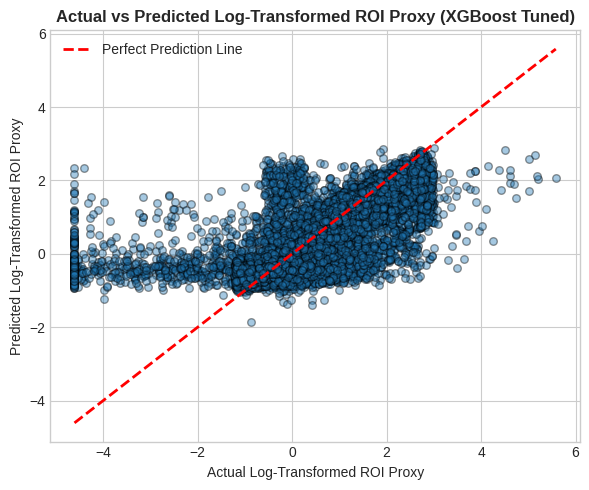

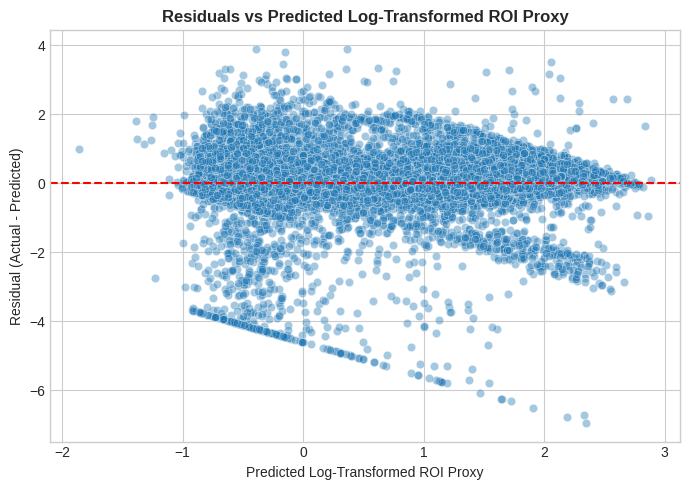

In [8]:
test_preds_log = best_model.predict(X_test)
y_test_roi = test_df['roi_clipped'].values

# Inverse-transform predictions from log scale to the clipped ROI Proxy ratio scale
test_preds_roi = np.clip(np.expm1(test_preds_log), -0.99, None)

test_r2 = r2_score(y_test, test_preds_log)
test_rmse_log = np.sqrt(mean_squared_error(y_test, test_preds_log))
test_mae_log = mean_absolute_error(y_test, test_preds_log)
test_mae_roi = mean_absolute_error(y_test_roi, test_preds_roi)

heldout_metrics_df = pd.DataFrame({
    'Evaluation Metric': [
        'Held-Out Test Set R² (Log Scale)',
        'Held-Out Test Set RMSE (Log Scale)',
        'Held-Out Test Set MAE (Log Scale)',
        'Held-Out Test Set MAE (Clipped ROI Proxy Ratio)',
        'Held-Out Test Set MAE (Clipped ROI Proxy Percentage Points)'
    ],
    'Score / Value': [
        f"{test_r2:.4f}",
        f"{test_rmse_log:.4f}",
        f"{test_mae_log:.4f}",
        f"{test_mae_roi:.4f}",
        f"{test_mae_roi * 100:.2f} percentage points"
    ]
})

print("="*105)
print("HELD-OUT TEST EVALUATION METRICS")
print("="*105)
print(heldout_metrics_df.to_string(index=False))

performance_summary = pd.DataFrame({
    'Metric': [
        'R²',
        'RMSE – Log-Transformed ROI Proxy',
        'MAE – Log-Transformed ROI Proxy',
        'MAE – Clipped ROI Proxy Ratio'
    ],
    'Hyperparameter-Selection CV': [
        round(hyperparameter_selection_cv_r2, 4),
        '—',
        '—',
        '—'
    ],
    'Held-Out Test': [
        round(test_r2, 4),
        round(test_rmse_log, 4),
        round(test_mae_log, 4),
        round(test_mae_roi, 4)
    ]
})

print("\n" + "="*105)
print("PERFORMANCE SUMMARY TABLE: HYPERPARAMETER-SELECTION CV VS HELD-OUT TEST")
print("="*105)
print(performance_summary.to_string(index=False))
print("\n")

plt.figure(figsize=(6, 5))
plt.scatter(y_test, test_preds_log, alpha=0.4, edgecolors='k', s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.title(f"Actual vs Predicted Log-Transformed ROI Proxy ({best_baseline_model} Tuned)", fontsize=12, fontweight='bold')
plt.xlabel("Actual Log-Transformed ROI Proxy")
plt.ylabel("Predicted Log-Transformed ROI Proxy")
plt.legend()
plt.tight_layout()
plt.show()

residuals_log = y_test - test_preds_log
plt.figure(figsize=(7, 5))
sns.scatterplot(x=test_preds_log, y=residuals_log, alpha=0.4)
plt.axhline(0, linestyle='--', linewidth=1.5, color='red')
plt.title("Residuals vs Predicted Log-Transformed ROI Proxy", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Log-Transformed ROI Proxy")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

## **Section 8: Feature Importance Analysis**
Feature importance measures are used to identify the features that contribute most to the fitted model's predictions. For tree-based models, the model's built-in feature importance is used; for linear models, the absolute coefficient magnitude is used as a relative measure within the fitted feature representation. These measures indicate model reliance rather than causal effects. This is visualised via a horizontal bar plot.

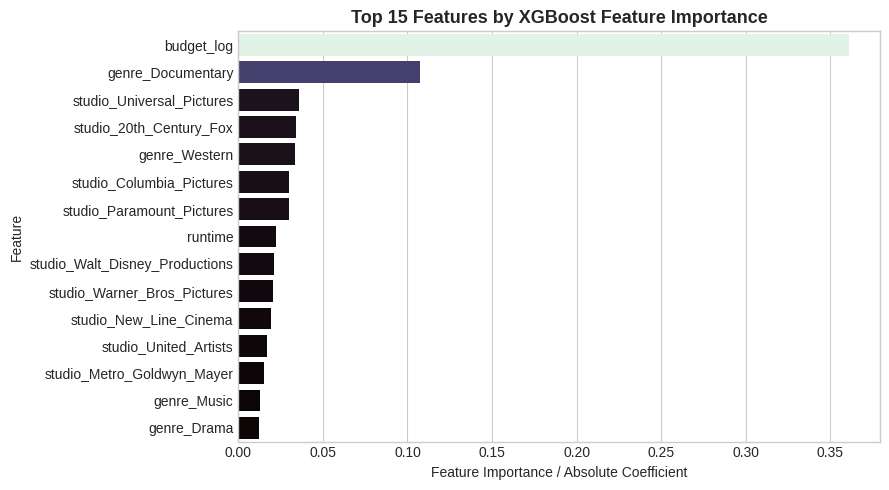

In [9]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
elif hasattr(best_model, 'coef_'):
    importances = pd.Series(np.abs(best_model.coef_), index=X_train.columns).sort_values(ascending=False).head(15)
else:
    raise ValueError(f"Feature importance is not available for {best_baseline_model}.")

plt.figure(figsize=(9, 5))

norm = plt.Normalize(importances.min(), importances.max())
cmap_mako = plt.get_cmap("mako")
colors = [cmap_mako(norm(val)) for val in importances.values]

sns.barplot(
    x=importances.values,
    y=importances.index,
    hue=importances.index,
    palette=colors,
    legend=False
)

plt.title(
    f"Top 15 Features by {best_baseline_model} Feature Importance",
    fontsize=13,
    fontweight='bold'
)
plt.xlabel("Feature Importance / Absolute Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## **Section 9: Genre-Level Performance Analysis**
Genre-level performance is evaluated across genre categories within the held-out test split to assess whether predictive performance varies across different genre segments. As films may belong to multiple genres, the same film may contribute to more than one genre-level analysis. Metrics are reported only for genres with at least 10 held-out test observations, and results should be interpreted alongside subgroup sample sizes.

In [10]:
subgroup_results = []
genre_cols_list = [c for c in X_train.columns if c.startswith('genre_')]

for g_col in genre_cols_list:
    mask = X_test[g_col] == 1
    if mask.sum() >= 10:
        sub_y_log = y_test[mask]
        sub_pred_log = test_preds_log[mask]
        sub_y_roi = y_test_roi[mask]
        sub_pred_roi = test_preds_roi[mask]

        subgroup_r2 = r2_score(sub_y_log, sub_pred_log) if sub_y_log.nunique() > 1 else np.nan

        subgroup_results.append({
            'Genre Subgroup': g_col.replace('genre_', ''),
            'Test Sample Size': int(mask.sum()),
            'Genre R² (Log Scale)': round(subgroup_r2, 4) if not np.isnan(subgroup_r2) else np.nan,
            'Genre RMSE (Log Scale)': round(np.sqrt(mean_squared_error(sub_y_log, sub_pred_log)), 4),
            'Genre MAE (Clipped ROI Proxy Ratio Scale)': round(mean_absolute_error(sub_y_roi, sub_pred_roi), 4)
        })

if subgroup_results:
    df_subgroup = pd.DataFrame(subgroup_results).sort_values(by='Genre MAE (Clipped ROI Proxy Ratio Scale)').reset_index(drop=True)
    print("="*120)
    print("GENRE-LEVEL PERFORMANCE SUMMARY")
    print("="*120)
    print(df_subgroup.to_string(index=False))
else:
    print("[INFO] No genre subgroups met the minimum sample size threshold of 10 observations.")

GENRE-LEVEL PERFORMANCE SUMMARY
 Genre Subgroup  Test Sample Size  Genre R² (Log Scale)  Genre RMSE (Log Scale)  Genre MAE (Clipped ROI Proxy Ratio Scale)
       TV_Movie              2621                0.7462                  0.4376                                     0.4865
          Music              2741                0.6194                  0.6283                                     0.7397
         Horror              3122                0.5519                  0.7035                                     0.8071
       Thriller              3352                0.4070                  0.8749                                     0.8476
         Comedy              5416                0.4848                  0.8195                                     0.8527
Science_Fiction              1244                0.4636                  0.7914                                     0.8618
          Drama              7655                0.5195                  0.8257                            

## **Section 10: Business Deliverables**

### 10.1 Core Standalone Deliverable: Illustrative Historical ROI Proxy Ranking of Held-Out Test Films

Held-out test films are ranked by predicted ROI Proxy, obtained by applying the inverse of the log transformation to the model's predicted log ROI Proxy values, to illustrate how the model could support content-screening and prioritisation decisions. This ranking is based on model predictions and is not a validated estimate of future financial performance or licensing profitability. Actual revenue and actual ROI Proxy are shown only for retrospective validation; neither is used as a model input or pre-release decision variable.

### 10.2 Business Evaluation & Recommendations

The model evaluates the extent to which the selected pre-release-available features provide predictive signal for historical ROI Proxy outcomes. Performance on the untouched held-out test set is reported above using R² and Mean Absolute Error (MAE) on the log-transformed ROI Proxy scale.

The predicted ROI Proxy rankings can therefore be used as one exploratory screening input for content acquisition and portfolio prioritisation, rather than as a standalone automated licensing decision. To maximise business impact, the model should be supplemented by commercial factors such as expected audience demand, licensing cost, market fit, and qualitative curation assessment.

### 10.3 Business Issues Identified

To ensure transparent governance and address limitations proactively, the following commercial and operational issues should be noted:

- **Simplified Financial Measure:** The ROI Proxy is a simplified financial ratio and does not capture full licensing profitability, marketing expenses, or ongoing distribution costs.

- **Timing Discrepancies:** Historical release timing may not precisely reflect the information or market conditions available at the original pre-release acquisition decision point.

- **Uncaptured Commercial Factors:** The available dataset omits unobserved market factors such as star power, marketing spend, and streaming platform exclusivity terms that heavily influence content performance.

In [11]:
df_test_eval = test_df[['title', 'budget', 'revenue', 'roi_clipped', 'genre_names']].copy()
df_test_eval['predicted_log_roi'] = test_preds_log

# Inverse-transform predictions with consistent lower-bound clipping
df_test_eval['predicted_roi_pct'] = np.clip(
    np.expm1(df_test_eval['predicted_log_roi']),
    -0.99,
    None
) * 100

df_test_eval['actual_roi_proxy_pct'] = df_test_eval['roi_clipped'] * 100

print(
    f"On the untouched held-out test set, the model achieves an R² of "
    f"{test_r2:.4f} (Log Scale) with a Mean Absolute Error of "
    f"{test_mae_log:.4f}."
)

print("\n" + "="*150)
print("CORE BUSINESS DELIVERABLE: ILLUSTRATIVE HISTORICAL ROI PROXY RANKING OF HELD-OUT TEST FILMS (TOP 20)")
print("="*150)

shortlist = df_test_eval.sort_values(by='predicted_roi_pct', ascending=False).head(20)
shortlist_display = shortlist[['title', 'genre_names', 'budget', 'actual_roi_proxy_pct', 'predicted_roi_pct']].copy()
shortlist_display['actual_roi_proxy_pct'] = shortlist_display['actual_roi_proxy_pct'].apply(lambda x: f"{x:,.0f}%")
shortlist_display['predicted_roi_pct'] = shortlist_display['predicted_roi_pct'].apply(lambda x: f"{x:,.0f}%")
shortlist_display['budget'] = shortlist_display['budget'].apply(lambda x: f"${x:,.0f}")
print(shortlist_display.to_string(index=False))

df_full_export = df_test_eval.sort_values(by='predicted_roi_pct', ascending=False).reset_index(drop=True)
df_full_export.index += 1
df_full_export.index.name = 'Rank'

try:
    df_full_export.to_csv('/content/drive/MyDrive/Full_Ranked_ROI_Proxy_Pipeline.csv')
    df_full_export.head(20).to_csv('/content/drive/MyDrive/Top_20_Historical_ROI_Proxy_Ranking.csv')
    print("\n[SUCCESS] Exported the retrospective ranked predictions to Google Drive.")
except Exception as e:
    print(f"\n[WARNING] Export to Google Drive skipped: {e}")

On the untouched held-out test set, the model achieves an R² of 0.6163 (Log Scale) with a Mean Absolute Error of 0.3897.

CORE BUSINESS DELIVERABLE: ILLUSTRATIVE HISTORICAL ROI PROXY RANKING OF HELD-OUT TEST FILMS (TOP 20)
                       title                                           genre_names     budget actual_roi_proxy_pct predicted_roi_pct
                 Road to Rio           ['Comedy', 'Adventure', 'Music', 'Romance']   $155,486               1,896%            1,701%
From All of Us to All of You         ['Animation', 'Comedy', 'Family', 'TV Movie']   $205,062                 578%            1,653%
                  Cinderella         ['Family', 'Fantasy', 'Animation', 'Romance'] $2,900,000               8,990%            1,602%
       Outlaws of Pine Ridge                                           ['Western']   $110,527               1,393%            1,574%
 Renegades of the Rio Grande                                           ['Western']   $105,626               1,47

ILLUSTRATIVE INTEGRATION FRAMEWORK WITH OBJECTIVE 3 ANALYSIS
[INFO] DEMONSTRATION ONLY: Portfolio tiers are illustrative because the objective 3 classification score is a synthetic placeholder rather than an analytical result. No substantive conclusions should be drawn from these illustrative tier assignments.

                                               Portfolio Tier  Movie Count
Tier 3: Lower Predicted ROI Proxy & High Classification Score         8609
 Tier 1: High Predicted ROI Proxy & High Classification Score         8578
Tier 2: High Predicted ROI Proxy & Lower Classification Score         7668
                                         Tier 4: Low Priority         7638

[INFO] Illustrative integrated team deliverable successfully exported to: /content/drive/MyDrive/Illustrative_Integrated_Team_Deliverable.csv



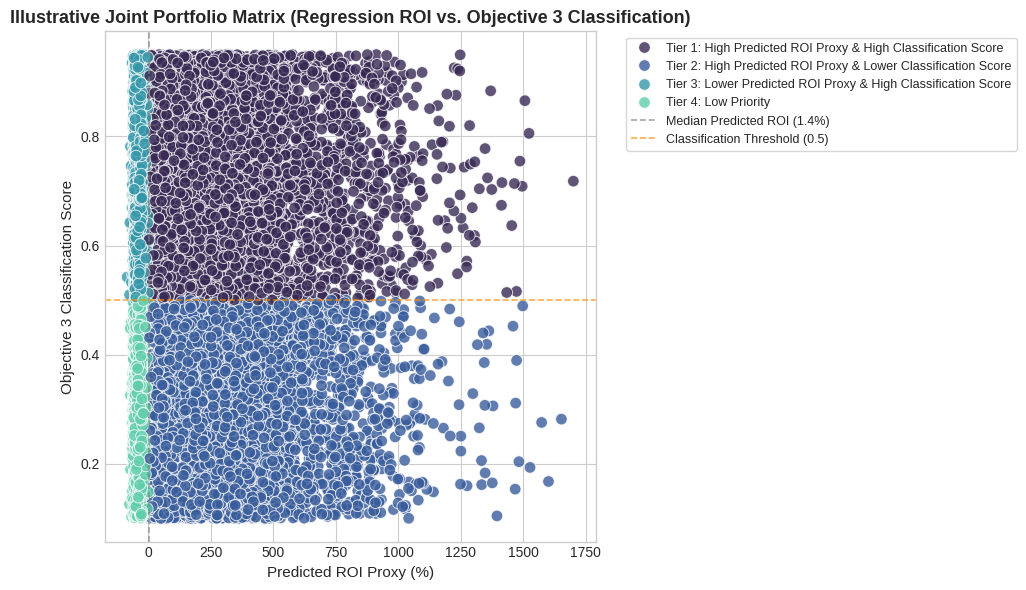

In [12]:
# Illustrative Integration Framework with Objective 3's Classification / Catalogue Analysis
print("="*105)
print("ILLUSTRATIVE INTEGRATION FRAMEWORK WITH OBJECTIVE 3 ANALYSIS")
print("="*105)
np.random.seed(42)

df_test_eval['objective3_classification_score'] = np.random.uniform(
    0.1, 0.95, size=len(df_test_eval)
)

def assign_portfolio_quadrant(row):
    high_roi = row['predicted_roi_pct'] > df_test_eval['predicted_roi_pct'].median()
    high_classification = row['objective3_classification_score'] > 0.5

    if high_roi and high_classification:
        return 'Tier 1: High Predicted ROI Proxy & High Classification Score'
    elif high_roi and not high_classification:
        return 'Tier 2: High Predicted ROI Proxy & Lower Classification Score'
    elif not high_roi and high_classification:
        return 'Tier 3: Lower Predicted ROI Proxy & High Classification Score'
    else:
        return 'Tier 4: Low Priority'

df_test_eval['portfolio_tier'] = df_test_eval.apply(assign_portfolio_quadrant, axis=1)

tier_summary = df_test_eval['portfolio_tier'].value_counts().reset_index()
tier_summary.columns = ['Portfolio Tier', 'Movie Count']

print(
    "[INFO] DEMONSTRATION ONLY: Portfolio tiers are illustrative because "
    "the objective 3 classification score is a synthetic placeholder rather "
    "than an analytical result. No substantive conclusions should be drawn "
    "from these illustrative tier assignments." + "\n"
)
print(tier_summary.to_string(index=False))

integrated_output_path = '/content/drive/MyDrive/Illustrative_Integrated_Team_Deliverable.csv'
df_test_eval[['title', 'budget', 'predicted_roi_pct', 'objective3_classification_score', 'portfolio_tier']].to_csv(integrated_output_path, index=False)
print(f"\n[INFO] Illustrative integrated team deliverable successfully exported to: {integrated_output_path}\n")

# VISUAL PORTFOLIO QUADRANT MATRIX PLOT
plt.figure(figsize=(10, 6))

median_roi = df_test_eval['predicted_roi_pct'].median()
threshold_class = 0.5

tier_order = [
    'Tier 1: High Predicted ROI Proxy & High Classification Score',
    'Tier 2: High Predicted ROI Proxy & Lower Classification Score',
    'Tier 3: Lower Predicted ROI Proxy & High Classification Score',
    'Tier 4: Low Priority'
]

sns.scatterplot(
    data=df_test_eval,
    x='predicted_roi_pct',
    y='objective3_classification_score',
    hue='portfolio_tier',
    hue_order=tier_order,
    palette='mako',
    alpha=0.8,
    s=70,
    edgecolor='w'
)

plt.axvline(median_roi, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, label=f'Median Predicted ROI ({median_roi:.1f}%)')
plt.axhline(threshold_class, color='darkorange', linestyle='--', linewidth=1.2, alpha=0.7, label=f'Classification Threshold ({threshold_class})')

plt.title(
    "Illustrative Joint Portfolio Matrix (Regression ROI vs. Objective 3 Classification)",
    fontsize=13,
    fontweight='bold'
)
plt.xlabel("Predicted ROI Proxy (%)", fontsize=11)
plt.ylabel("Objective 3 Classification Score", fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fontsize=9)
plt.tight_layout()
plt.show()

In [13]:
cv_r2_val = hyperparameter_selection_cv_r2
test_r2_val = test_r2
test_rmse_val = test_rmse_log
test_mae_val = test_mae_log
cv_test_delta = abs(cv_r2_val - test_r2_val)
winning_model_name = f"{best_baseline_model} (Tuned)"
business_objective_assessment = "Partially / Sufficiently for exploratory screening"

summary_table = pd.DataFrame({
    "Evaluation Metric": [
        f"Best Hyperparameter-Selection CV R² ({len(cv_splits)}-Fold)",
        "Held-Out Test Set R²",
        "Generalisation Delta (|CV - Test|)",
        "Log-Scale Test RMSE",
        "Log-Scale Test MAE",
        "Optimal Winning Model"
    ],
    "Recorded Value": [
        f"{cv_r2_val:.4f}",
        f"{test_r2_val:.4f}",
        f"{cv_test_delta:.4f}",
        f"{test_rmse_val:.4f}",
        f"{test_mae_val:.4f}",
        winning_model_name
    ],
    "Assessment Implications": [
        "Cross-validation performance used during model selection",
        "Out-of-sample predictive performance on the untouched test set",
        "Difference between cross-validation and held-out test performance",
        "Prediction error measured on the log-transformed target",
        "Average absolute prediction error on the log-transformed target",
        "Selected through random search over a predefined parameter space"
    ]
})

print("="*105)
print("                    DYNAMIC PIPELINE EVALUATION & METRICS SUMMARY")
print("="*105)
display(summary_table)

print("\n" + "="*105)
print("              SYNTHESIS OF FINDINGS, EVALUATION & BUSINESS RECOMMENDATIONS")
print("="*105)
print(f"1. EMPIRICAL FINDINGS & GENERALISATION:")
print(f"   - Cross-Validation R²: {cv_r2_val:.4f} | Held-Out Test R²: {test_r2_val:.4f}")
print(f"   - Generalisation Delta: {cv_test_delta:.4f} (CV and held-out test performance are closely aligned).")

print("\n2. MODEL EVALUATION CONCLUSION (DOES IT ACHIEVE THE BUSINESS OBJECTIVE?):")
print(f"   - Business Objective Assessment: {business_objective_assessment}.")
print(
    f"   - Supportive Evidence: The held-out test R² ({test_r2_val:.4f}) "
    f"provides evidence of predictive signal from the available content-related "
    f"features using the {winning_model_name}."
)
print(
    f"   - Interpretation: The cross-validation and held-out test R² differ by "
    f"{cv_test_delta:.4f}, indicating closely aligned performance in this evaluation."
)
print(
    "   - Limitations: The target is a historical ROI Proxy rather than direct "
    "licensing profitability, and the available features do not capture all "
    "commercial factors that may influence content performance."
)

print("\n3. BUSINESS ISSUES IDENTIFIED FOR EARLIER CONSIDERATION:")
print(
    "   - Commercial Profitability Definition: The ROI Proxy does not represent "
    "actual licensing profitability; licensing costs and other commercial cost "
    "components should be incorporated into a future target definition."
)
print(
    "   - Pre-Release Information Availability: Historical release timing may "
    "not precisely reflect the information available at the original acquisition "
    "decision point."
)
print(
    "   - Commercial Context: Factors such as audience demand, marketing "
    "investment, market fit and platform-specific commercial terms are not "
    "captured in the available data."
)

print("\n4. ACTIONABLE BUSINESS RECOMMENDATIONS:")
print(
    f"   - Use as a Pre-Screening Tool: Apply predictions from the "
    f"{winning_model_name} as one input for initial content screening and "
    f"prioritisation, rather than as a standalone decision rule."
)
print(
    "   - Human-in-the-Loop Oversight: Retain human review when interpreting "
    "model predictions, particularly for higher-impact licensing decisions."
)
print(
    "   - Account for Subgroup Performance: Consider differences in predictive "
    "performance across genres alongside subgroup sample sizes."
)
print(
    "   - Refine Commercial Data: Incorporate actual licensing costs and other "
    "relevant commercial factors in future iterations to develop a target more "
    "closely aligned with licensing profitability."
)
print("="*105)

                    DYNAMIC PIPELINE EVALUATION & METRICS SUMMARY


,Evaluation Metric,Recorded Value,Assessment Implications
0,Best Hyperparameter-Selection CV R² (5-Fold),0.6159,Cross-validation performance used during model...
1,Held-Out Test Set R²,0.6163,Out-of-sample predictive performance on the un...
2,Generalisation Delta (|CV - Test|),0.0004,Difference between cross-validation and held-o...
3,Log-Scale Test RMSE,0.6939,Prediction error measured on the log-transform...
4,Log-Scale Test MAE,0.3897,Average absolute prediction error on the log-t...
5,Optimal Winning Model,XGBoost (Tuned),Selected through random search over a predefin...



              SYNTHESIS OF FINDINGS, EVALUATION & BUSINESS RECOMMENDATIONS
1. EMPIRICAL FINDINGS & GENERALISATION:
   - Cross-Validation R²: 0.6159 | Held-Out Test R²: 0.6163
   - Generalisation Delta: 0.0004 (CV and held-out test performance are closely aligned).

2. MODEL EVALUATION CONCLUSION (DOES IT ACHIEVE THE BUSINESS OBJECTIVE?):
   - Business Objective Assessment: Partially / Sufficiently for exploratory screening.
   - Supportive Evidence: The held-out test R² (0.6163) provides evidence of predictive signal from the available content-related features using the XGBoost (Tuned).
   - Interpretation: The cross-validation and held-out test R² differ by 0.0004, indicating closely aligned performance in this evaluation.
   - Limitations: The target is a historical ROI Proxy rather than direct licensing profitability, and the available features do not capture all commercial factors that may influence content performance.

3. BUSINESS ISSUES IDENTIFIED FOR EARLIER CONSIDERATION:
   

## **Section 11: Responsible AI Framework & Limitations**
### Responsible AI Framework & Risk Assessment
| Ethical Risk | Potential Impact | Assessment / Control / Mitigation Applied | Remaining Limitation |
| :--- | :--- | :--- | :--- |
| **Data Selection Bias** | Model applies only to the defined modelling population. | Scope filters documented; excluded records quantified. | Model is trained only on the defined modelling population; results may not generalise to films outside the defined U.S.-origin, English-language, financial and duration scope. |
| **Pre-Release Availability** | Historical dates may reflect post-scheduling changes. | Features were selected based on their intended pre-release availability; historical release dates represent observed timing and may differ from the originally planned release timing. | Some historical metadata may not have been known or fixed at the exact pre-release decision point. |
| **Target & Measurement Bias** | ROI Proxy may be misinterpreted as full financial profit. | Target explicitly defined as an ROI Proxy. | Marketing, distribution and other costs are not captured. |
| **Historical Bias** | Model reproduces legacy distribution biases. | Historical scope documented; genre subgroup performance assessed. | Model may reproduce patterns and biases present in historical film-market data; changes in future market conditions and audience preferences may reduce generalisability. |
| **Automation Bias** | Over-reliance on numerical portfolio scores. | Outputs are positioned as decision support requiring human oversight rather than as an automated decision-making mechanism. | Qualitative human judgement remains required. |

In [14]:
rai_audit_df = pd.DataFrame({
    'Responsible AI Category': [
        '1. Data Selection Bias',
        '2. Pre-Release Availability',
        '3. Target & Measurement Bias',
        '4. Historical Bias',
        '5. Automation Bias'
    ],
    'Status / Control Applied': [
        'Scope filters documented and excluded records quantified.',
        'Features selected based on intended pre-release availability; historical timing limitations acknowledged.',
        'Target explicitly defined as an ROI Proxy rather than full financial profit.',
        'Historical data limitations acknowledged and genre subgroup performance assessed.',
        'Outputs positioned as decision support requiring human oversight.'
    ]
})

print("="*150)
print(f"{'Responsible AI Category':<30} | {'Status / Control Applied'}")
print("="*150)
for _, row in rai_audit_df.iterrows():
    print(f"{row['Responsible AI Category']:<30} | {row['Status / Control Applied']}")
print("="*150)

Responsible AI Category        | Status / Control Applied
1. Data Selection Bias         | Scope filters documented and excluded records quantified.
2. Pre-Release Availability    | Features selected based on intended pre-release availability; historical timing limitations acknowledged.
3. Target & Measurement Bias   | Target explicitly defined as an ROI Proxy rather than full financial profit.
4. Historical Bias             | Historical data limitations acknowledged and genre subgroup performance assessed.
5. Automation Bias             | Outputs positioned as decision support requiring human oversight.


## **Section 12: Conclusion & Summary**
This module delivers a regression pipeline with documented leakage controls for predicting historical movie ROI Proxy outcomes from attributes intended to be available before release. It provides baseline model comparison, hyperparameter optimisation, held-out performance evaluation, quantitative ROI Proxy predictions, and genre-level subgroup diagnostics.

In [15]:
print("[INFO] Pipeline execution complete. Outputs are available for evaluation and illustrative app-team integration.")

[INFO] Pipeline execution complete. Outputs are available for evaluation and illustrative app-team integration.
